#AI Tools

In [45]:
#link to the Kaggle dataset -> https://www.kaggle.com/datasets/devadigax/aitoolbuzz-com-16k-ai-tools-database

import pandas as pd
import numpy as np

##Data Exploration

In [46]:
df_ai_tools = pd.read_csv("/content/AI Tools Dataset 2025 - 16763 Tools from AIToolBuzz.csv")

In [47]:
df_ai_tools.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16762 entries, 0 to 16761
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               16762 non-null  object 
 1   Link               16762 non-null  object 
 2   Logo               16537 non-null  object 
 3   Category           16762 non-null  object 
 4   Primary Task       16762 non-null  object 
 5   Keywords           9529 non-null   object 
 6   Year Founded       5831 non-null   float64
 7   Short Description  16232 non-null  object 
 8   Country            6628 non-null   object 
 9   industry           7827 non-null   object 
 10  technologies       7633 non-null   object 
 11  Website            16762 non-null  object 
 12  Website Status     16735 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.7+ MB


In [48]:
"""
------------------------------------
Column Descriptions (source: Kaggle)
------------------------------------


Name
    Tool’s official name.

Link
    URL of its page on AIToolBuzz.

Logo
    Direct logo image URL.

Category
    Functional domain (e.g., Communication, Marketing, Development).

Primary Task
    Main purpose or capability.

Keywords
    Comma-separated tags describing tool functions and industries.

Year Founded
    Year of company/tool inception.

Short Description
    Concise summary of the tool.

Country
    Headquarters or operating country.

industry
    Industry classification.

technologies
    Key technologies or frameworks associated.

Website
    Official product/company website.

Website Status
    Website availability (e.g., Active, Error, Not Reachable).
"""

'\n------------------------------------\nColumn Descriptions (source: Kaggle)\n------------------------------------\n\n\nName\n    Tool’s official name.\n\nLink\n    URL of its page on AIToolBuzz.\n\nLogo\n    Direct logo image URL.\n\nCategory\n    Functional domain (e.g., Communication, Marketing, Development).\n\nPrimary Task\n    Main purpose or capability.\n\nKeywords\n    Comma-separated tags describing tool functions and industries.\n\nYear Founded\n    Year of company/tool inception.\n\nShort Description\n    Concise summary of the tool.\n\nCountry\n    Headquarters or operating country.\n\nindustry\n    Industry classification.\n\ntechnologies\n    Key technologies or frameworks associated.\n\nWebsite\n    Official product/company website.\n\nWebsite Status\n    Website availability (e.g., Active, Error, Not Reachable).\n'

In [49]:
df_ai_tools.describe(include='all')

,Name,Link,Logo,Category,Primary Task,Keywords,Year Founded,Short Description,Country,industry,technologies,Website,Website Status
count,16762,16762,16537,16762,16762,9529,5831.000000,16232,6628,7827,7633,16762,16735
unique,16609,16762,16524,14,3495,7875,NaN,16213,99,95,6817,16744,30
top,AI Prompt Generator,https://aitoolbuzz.com/z-ai,https://aitoolbuzz.com/tools/logo/pixelvibe.svg,Media And Content Creation,Content,"technology, information & internet, informatio...",NaN,Chat with your PDFs in seconds.,United States,information technology & services,Mobile Friendly,?ref=aitoolbuzz.com,Active
freq,5,1,2,4289,393,580,NaN,2,3674,5945,85,19,14038
mean,NaN,NaN,NaN,NaN,NaN,NaN,2020.511233,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,4.705878,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,1969.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,2022.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,2023.000000,NaN,NaN,NaN,NaN,NaN,NaN


In [50]:
columns = [
    'Name', 'Link', 'Logo', 'Category', 'Primary Task', 'Keywords',
    'Year Founded', 'Short Description', 'Country', 'industry',
    'technologies', 'Website', 'Website Status'
]

for col in columns:
    missing = df_ai_tools[col].isna().sum()
    duplicated = df_ai_tools[col].duplicated().sum()
    total_non_null = df_ai_tools[col].count()

    print(f"--- {col} ---")
    print(f"Missing values:        {missing}")
    print(f"Duplicated values:     {duplicated}")
    print(f"Total non-null values: {total_non_null}\n")

--- Name ---
Missing values:        0
Duplicated values:     153
Total non-null values: 16762

--- Link ---
Missing values:        0
Duplicated values:     0
Total non-null values: 16762

--- Logo ---
Missing values:        225
Duplicated values:     237
Total non-null values: 16537

--- Category ---
Missing values:        0
Duplicated values:     16748
Total non-null values: 16762

--- Primary Task ---
Missing values:        0
Duplicated values:     13267
Total non-null values: 16762

--- Keywords ---
Missing values:        7233
Duplicated values:     8886
Total non-null values: 9529

--- Year Founded ---
Missing values:        10931
Duplicated values:     16720
Total non-null values: 5831

--- Short Description ---
Missing values:        530
Duplicated values:     548
Total non-null values: 16232

--- Country ---
Missing values:        10134
Duplicated values:     16662
Total non-null values: 6628

--- industry ---
Missing values:        8935
Duplicated values:     16666
Total non-nu

##Data Cleaning

In [51]:
#Name column

#Missing values:        0
#Duplicated values:     153
#Total non-null values: 16762

#convert Name to string
df_ai_tools['Name'] = df_ai_tools['Name'].astype(str)

#sometimes CSV or Excel imports add invisible characters that strip() won’t catch
#this keeps only standard ASCII characters
df_ai_tools['Name'] = df_ai_tools['Name'].str.replace(r"[^\x00-\x7F]+", "", regex=True)

In [52]:
#Link column
#example of values -> https://aitoolbuzz.com/chatgpt, https://aitoolbuzz.com/ai-fiesta

#Missing values:        0
#Duplicated values:     0
#Total non-null values: 16609

#convert Link to string
df_ai_tools['Link'] = df_ai_tools['Link'].astype(str)

#regex pattern
pattern_link = r"^https://aitoolbuzz\.com/[A-Za-z0-9-]+$"

#create mask
mask_links = df_ai_tools['Link'].str.match(pattern_link)

#count valid vs invalid
valid_links = mask_links.sum()
invalid_links = (~mask_links).sum()

print(f"Valid Link values: {valid_links}")
print(f"Invalid Link values: {invalid_links}")

#display invalid ones
df_ai_tools.loc[~mask_links, 'Link'].value_counts()

#the 5 "invalid" values that don't match my rule match their respective "Name" entries
#example:
#Link entry: https://aitoolbuzz.com/b^-discover
#Name entry: B^ DISCOVER

Valid Link values: 16757
Invalid Link values: 5


,count
Link,
https://aitoolbuzz.com/b^-discover,1
https://aitoolbuzz.com/zoefit_bot,1
https://aitoolbuzz.com/yay!-forms,1
https://aitoolbuzz.com/recipe-now!,1
https://aitoolbuzz.com/go/nogo,1


In [53]:
#Logo column
#example of values -> https://aitoolbuzz.com/tools/logo/deepseek.png, https://aitoolbuzz.com/tools/logo/chatgpt.jpg

#Missing values:        225 (initial -> I converted those values to "nan")
#Duplicated values:     188 (I will not drop duplicates for this column, at least for now)
#Total non-null values: 16537

#convert Logo to string
df_ai_tools['Logo'] = df_ai_tools['Logo'].astype(str)

#when you do .astype(str) before fillna, all NaN values are converted to the string "nan",
#not actual NaN.
#fillna() only replaces real NaN values, not the string "nan"

#handle missing values
#df_ai_tools['Logo'] = df_ai_tools['Logo'].fillna('Unknown')

#regex pattern for Logo URLs
pattern_logo = r"^https://aitoolbuzz\.com/tools/logo/[A-Za-z0-9._-]+\.(png|jpg|jpeg|svg|webp|ai|io|app|com|audio|ico|xyz|art|cc|fm|me|chat|co|dev|energy|in)$"

#create mask
mask_logo = df_ai_tools['Logo'].str.match(pattern_logo)

#count valid vs invalid
valid_logo = mask_logo.sum()
invalid_logo = (~mask_logo).sum()

print(f"Valid Logo values: {valid_logo}")
print(f"Invalid Logo values: {invalid_logo}")

#display invalid logos
df_ai_tools.loc[~mask_logo, 'Logo'].value_counts()

Valid Logo values: 16537
Invalid Logo values: 225


,count
Logo,
nan,225


In [54]:
#Category column

#Missing values:        0
#Duplicated values:     16748
#Total non-null values: 16762

#convert Category to string
df_ai_tools['Category'] = df_ai_tools['Category'].astype(str)

df_ai_tools['Category'].value_counts()

,count
Category,
Media And Content Creation,4289
Communication And Support,2022
Technology And Development,1739
Operations And Management,1567
Marketing And Sales,1389
Ai And Machine Learning,1320
Business And Finance,1053
Specialized Technologies,967
Data And Analytics,765


In [55]:
#Primary Task column

#Missing values:        0
#Duplicated values:     13267
#Total non-null values: 16762

#convert Primary Task to string
df_ai_tools['Primary Task'] = df_ai_tools['Primary Task'].astype(str)

df_ai_tools['Primary Task'].value_counts()

,count
Primary Task,
Content,393
Images,373
Chatbots,217
Customer support,215
Chatting,213
...,...
Industrial design,1
Action figures,1
Answering questions about the Bhagavad Gita,1


In [56]:
#Keywords column

#Missing values:        7233 (initial)
#Duplicated values:     8886
#Total non-null values: 9529

#convert Keywords to string -> missing values become "nan"
df_ai_tools['Keywords'] = df_ai_tools['Keywords'].astype(str)

df_ai_tools['Keywords'].value_counts()

,count
Keywords,
nan,7233
"technology, information & internet, information technology & services",580
"software development, information technology & services",502
"it services & it consulting, information technology & services",91
education,66
...,...
"digital marketing & traditional marketing, marketing services, business startup tools, business intelligence, stress reduction plans, business idea validation, business tools automation, ai-powered business ideation, multi-language support, market research tools, health tech integration, software as a service (saas), business plan development, business growth strategies, wellness app features, guided meditations, business growth tools, business validation tools, entrepreneurship support, online",1
"AI, Advertising, Marketing, Ad copy, Creative generation, Automation",1
"AI, Image generation, Image editing, Style transfer, Machine learning",1


In [57]:
#Year Founded column

#Missing values:        10931 (initial)
#Duplicated values:     16720
#Total non-null values: 5831

#pandas has a special dtype called 'Int64' which supports real integers + NaN
#this automatically converts 2023.0 → 2023 & keeps missing values as <NA>
df_ai_tools['Year Founded'] = df_ai_tools['Year Founded'].astype('Int64')

#df_ai_tools['Year Founded'].isna().sum()
#output -> np.int64(10931)

df_ai_tools['Year Founded'].value_counts()

,count
Year Founded,
2023,1726
2024,854
2022,631
2021,458
2020,447
2019,292
2018,226
2017,205
2025,202


In [58]:
#Short Description column

#Missing values:        530 (initial)
#Duplicated values:     548
#Total non-null values: 16232

#convert Short Description to string -> missing values become "nan"
df_ai_tools['Short Description'] = df_ai_tools['Short Description'].astype(str)

df_ai_tools['Short Description'].value_counts()

,count
Short Description,
nan,530
Chat with your PDFs in seconds.,2
Your personal digital assistant powered by AI.,2
Enabling JavaScript to run your app.,2
Images,2
...,...
"WP AI Writer is an AI-powered content creation tool designed specifically for WordPress users. It helps generate various types of website content, including blog posts, articles, and marketing copy, saving time and effort.",1
"WP Now provides AI-powered news summaries, delivering concise and informative overviews of global events from various sources.",1
"Write 10X better, not just 10X faster",1


In [59]:
#Country column

#Missing values:        10134 (initial)
#Duplicated values:     16662
#Total non-null values: 6628

#convert Country to string -> missing values become "nan"
df_ai_tools['Country'] = df_ai_tools['Country'].astype(str)

df_ai_tools['Country'].value_counts()

#check if any entries contain digits -> Output: False
#(df_ai_tools['Country'].str.contains(r'\d', na=False)).any()

#check if any entries contain special characters -> Output: False
#(df_ai_tools['Country'].str.contains(r'[^a-zA-Z\s]', na=False)).any()

,count
Country,
nan,10134
United States,3674
United Kingdom,475
India,372
Canada,233
...,...
Panama,1
Sudan,1
Iran,1


In [60]:
#industry column

#Missing values:        8935 (initial)
#Duplicated values:     16666
#Total non-null values: 7827

#convert industry to string -> missing values become "nan"
df_ai_tools['industry'] = df_ai_tools['industry'].astype(str)

df_ai_tools['industry'].value_counts().head(10)

#check if any entries contain digits -> Output: False
#(df_ai_tools['industry'].str.contains(r'\d', na=False)).any()

#check if any entries contain special characters outside {' ', '&', ',', '-', '/'}
#-> Output: False
#(df_ai_tools['industry'].str.contains(r'[^a-zA-Z\s,&/\-]', na=False)).any()

,count
industry,
nan,8935
information technology & services,5945
marketing & advertising,223
education management,159
online media,130
information services,104
e-learning,83
financial services,79
writing & editing,62


In [61]:
#technologies column

#Missing values:        9129 (initial)
#Duplicated values:     9944
#Total non-null values: 7633

#convert technologies to string -> missing values become "nan"
df_ai_tools['technologies'] = df_ai_tools['technologies'].astype(str)

df_ai_tools['technologies'].value_counts().head(10)

#check if any entries contain special characters outside {'#','(',')',',','-','.','/'}
#-> Output: False
#(df_ai_tools['technologies'].str.contains(r'[^a-zA-Z0-9\s#(),\.\-/]', na=False)).any()

,count
technologies,
nan,9129
Mobile Friendly,85
Amazon AWS,45
"Cloudflare DNS, Gmail, Google Apps, CloudFlare Hosting",43
"Gmail, Google Apps",39
"Cloudflare DNS, CloudFlare Hosting, Mobile Friendly",29
"Gmail, Google Apps, Mobile Friendly",29
"Cloudflare DNS, CloudFlare Hosting",29
AI,20


In [62]:
#Website column

#Missing values:        0
#Duplicated values:     18
#Total non-null values: 16762

#convert Website to string
df_ai_tools['Website'] = df_ai_tools['Website'].astype(str)

#regex pattern: must start with 'http(s)://' and end with '?ref=aitoolbuzz.com'
pattern_website = r"^https?://.+\?ref=aitoolbuzz\.com$"

#create mask
mask_website = df_ai_tools['Website'].str.match(pattern_website)

#replace '?ref=aitoolbuzz.com' entries with 'Unknown'
df_ai_tools.loc[df_ai_tools['Website'] == "?ref=aitoolbuzz.com", 'Website'] = "Unknown"

#count valid vs invalid
valid_websites = mask_website.sum()
invalid_websites = (~mask_website).sum()

print(f"Valid Website values: {valid_websites}")
print(f"Invalid Website values: {invalid_websites}")

#display invalid ones
df_ai_tools.loc[~mask_website, 'Website'].value_counts()

Valid Website values: 16743
Invalid Website values: 19


,count
Website,
Unknown,19


In [63]:
#Website Status column

#Missing values:        27 (initial)
#Duplicated values:     16731
#Total non-null values: 16735

#convert Website Status to string -> missing values become "nan"
df_ai_tools['Website Status'] = df_ai_tools['Website Status'].astype(str)

df_ai_tools['Website Status'].value_counts().head(10)

,count
Website Status,
Active,14038
Not Reachable,1059
Error,543
Error 403,481
Error 404,316
Error 406,44
Error 436,40
Error 503,29
nan,27


##Data Visualization

In [74]:
#Name column -> we don't need to plot after Name column because each value is (mostly) unique

name_counts = df_ai_tools['Name'].value_counts().head(5)
print(name_counts)

Name
AI Prompt Generator    5
AI Music Generator     4
AI Poster Generator    3
GPT4All                3
Humanize AI Text       3
Name: count, dtype: int64


Link
https://aitoolbuzz.com/z-ai                 1
https://aitoolbuzz.com/chatgpt              1
https://aitoolbuzz.com/claude               1
https://aitoolbuzz.com/google-gemini        1
https://aitoolbuzz.com/microsoft-copilot    1
Name: count, dtype: int64


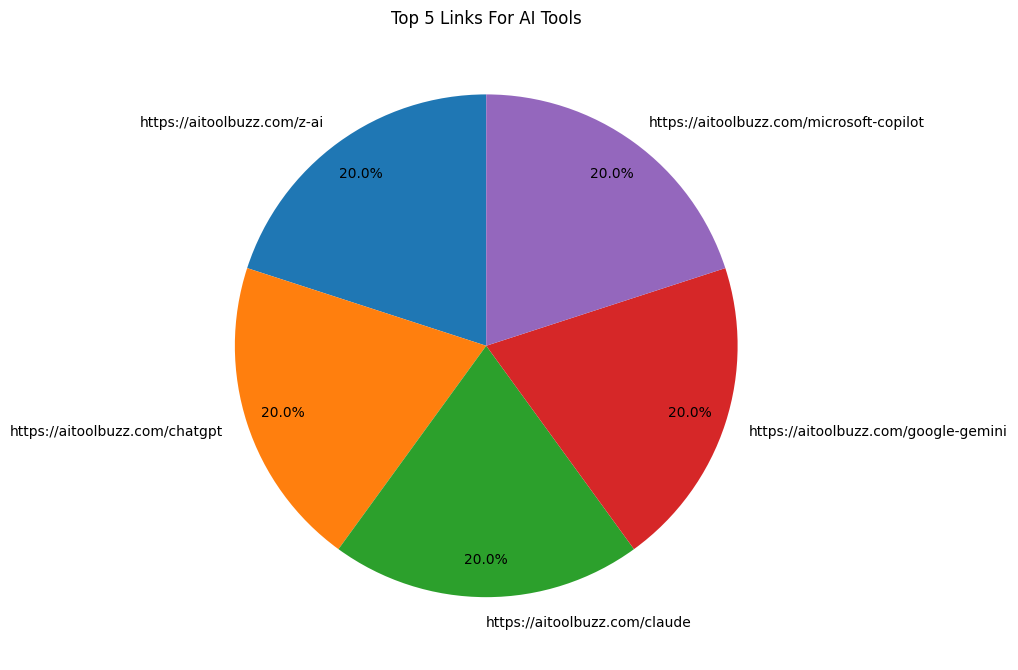

In [65]:
#Link column

link_counts = df_ai_tools['Link'].value_counts().head(5)
print(link_counts)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
link_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, pctdistance=0.85, legend=False)
plt.title('Top 5 Links For AI Tools')
plt.ylabel('')
plt.tight_layout()
plt.show()

Category
Media And Content Creation    4289
Communication And Support     2022
Technology And Development    1739
Operations And Management     1567
Marketing And Sales           1389
Ai And Machine Learning       1320
Business And Finance          1053
Specialized Technologies       967
Data And Analytics             765
Creative And Entertainment     580
Name: count, dtype: int64


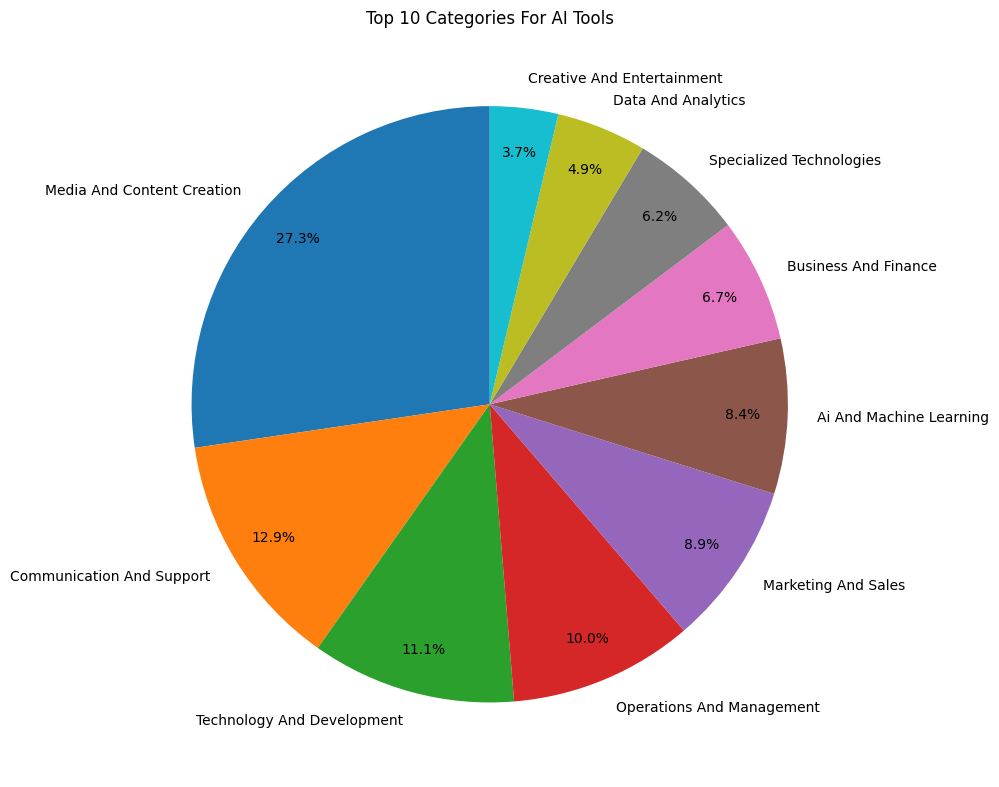

In [66]:
#Category column

category_counts = df_ai_tools['Category'].value_counts().head(10)
print(category_counts)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
category_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, pctdistance=0.85, legend=False)
plt.title('Top 10 Categories For AI Tools')
plt.ylabel('')
plt.tight_layout()
plt.show()

Primary Task
Content             393
Images              373
Chatbots            217
Customer support    215
Chatting            213
Name: count, dtype: int64


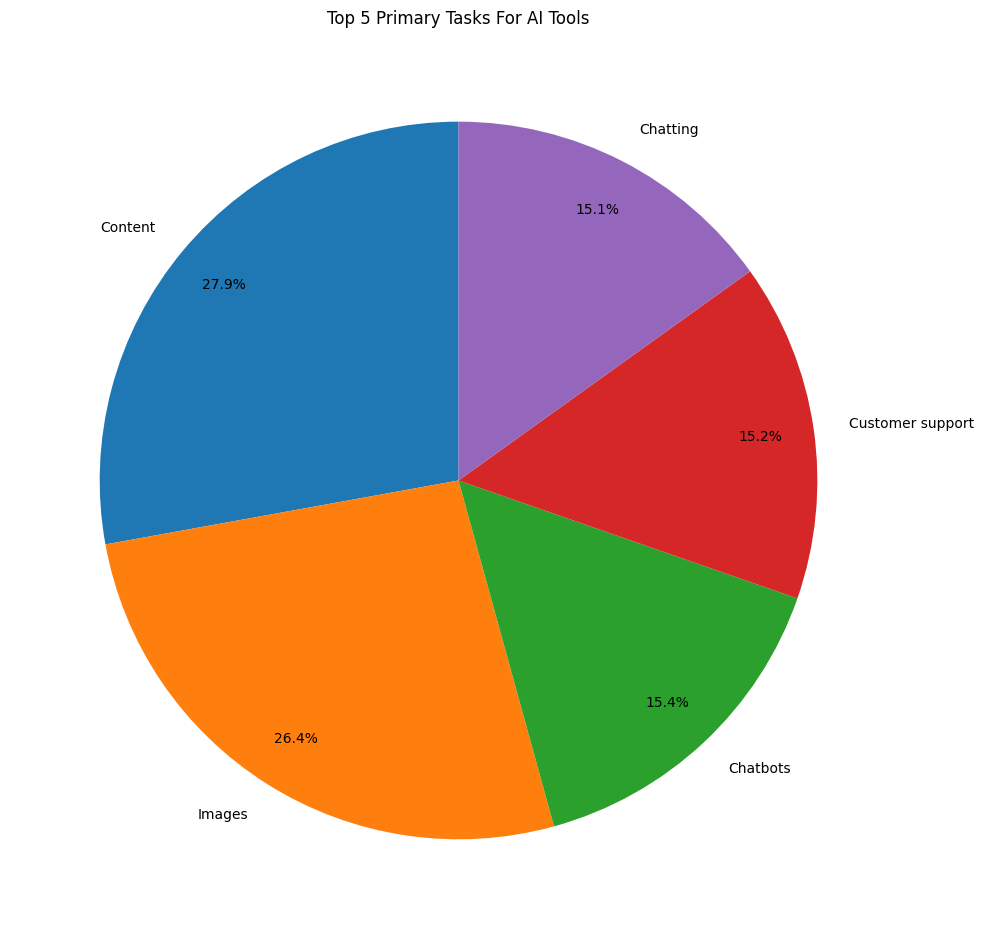

In [67]:
#Primary Task column

primary_task_counts = df_ai_tools['Primary Task'].value_counts().head(5)
print(primary_task_counts)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
primary_task_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, pctdistance=0.85, legend=False)
plt.title('Top 5 Primary Tasks For AI Tools')
plt.ylabel('')
plt.tight_layout()
plt.show()

keyword_single
nan                                    7233
software development                   3189
technology                             2444
information technology & services      2035
information & internet                 2034
artificial intelligence                1244
AI                                     1126
ai                                     1119
information technology and services     836
machine learning                        655
Name: count, dtype: int64


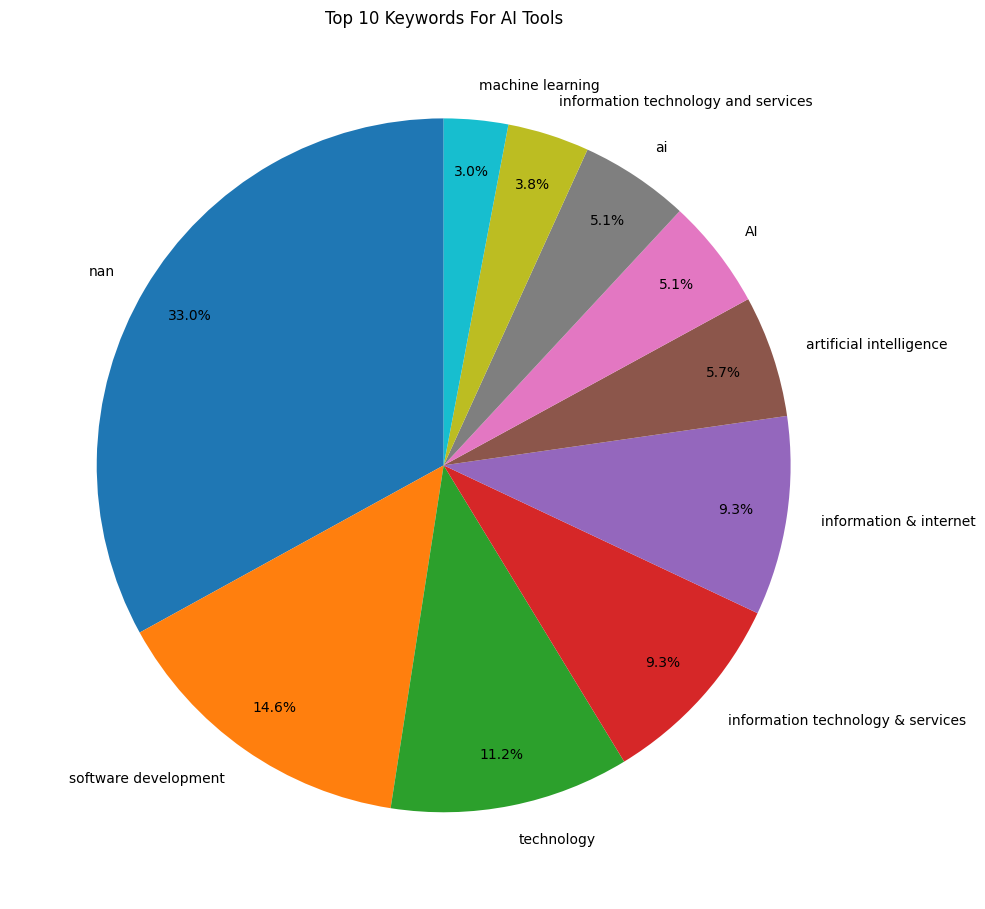

In [68]:
#Keywords column

#split keywords into lists, strip spaces, and stack into one column
keywords_single = df_ai_tools['Keywords'].astype(str).str.split(',').apply(pd.Series).stack().str.strip()

#convert back to a dataframe with the same column name
df_keywords = keywords_single.reset_index(drop=True).to_frame(name='keyword_single')

keywords_counts = df_keywords['keyword_single'].value_counts().head(10)
print(keywords_counts)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
keywords_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, pctdistance=0.85, legend=False)
plt.title('Top 10 Keywords For AI Tools')
plt.ylabel('')
plt.tight_layout()
plt.show()

Year Founded
2023    1726
2024     854
2022     631
2021     458
2020     447
Name: count, dtype: Int64


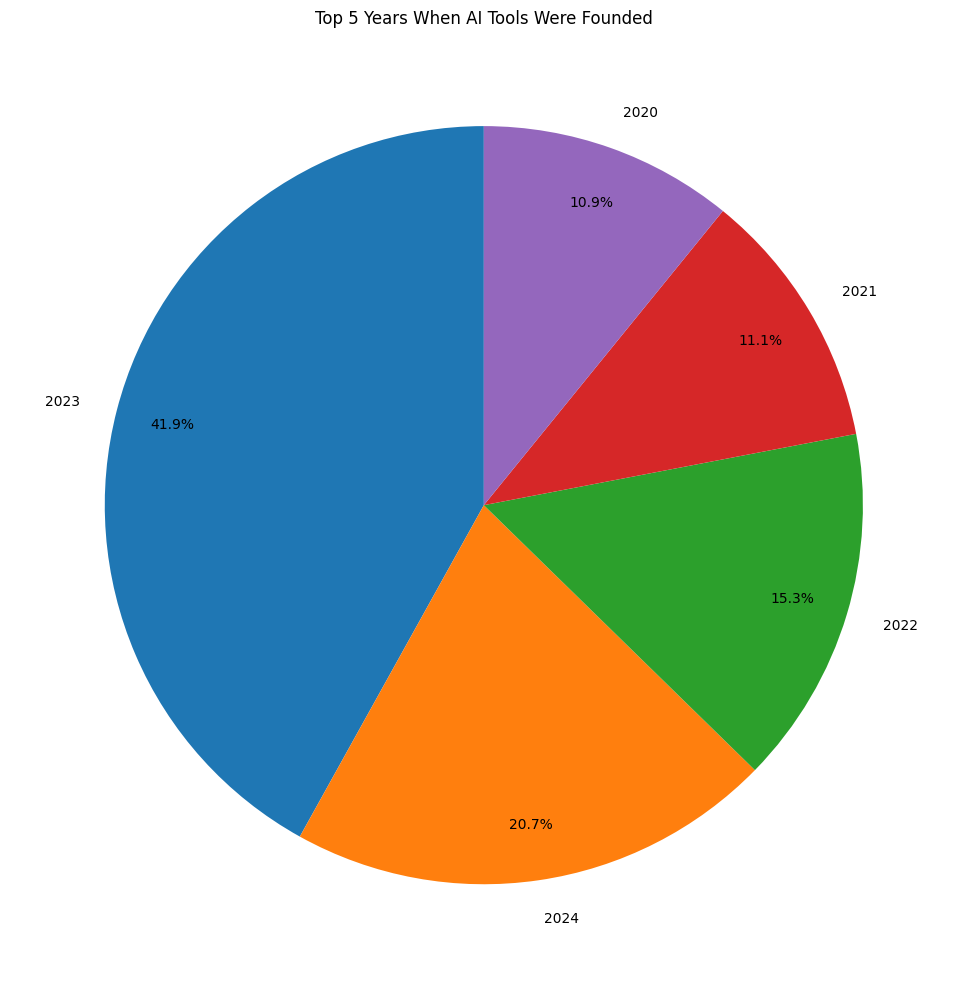

In [69]:
#Year Founded column

year_founded_counts = df_ai_tools['Year Founded'].value_counts().head(5)
print(year_founded_counts)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
year_founded_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, pctdistance=0.85, legend=False)
plt.title('Top 5 Years When AI Tools Were Founded')
plt.ylabel('')
plt.tight_layout()
plt.show()

Country
nan               10134
United States      3674
United Kingdom      475
India               372
Canada              233
Name: count, dtype: int64


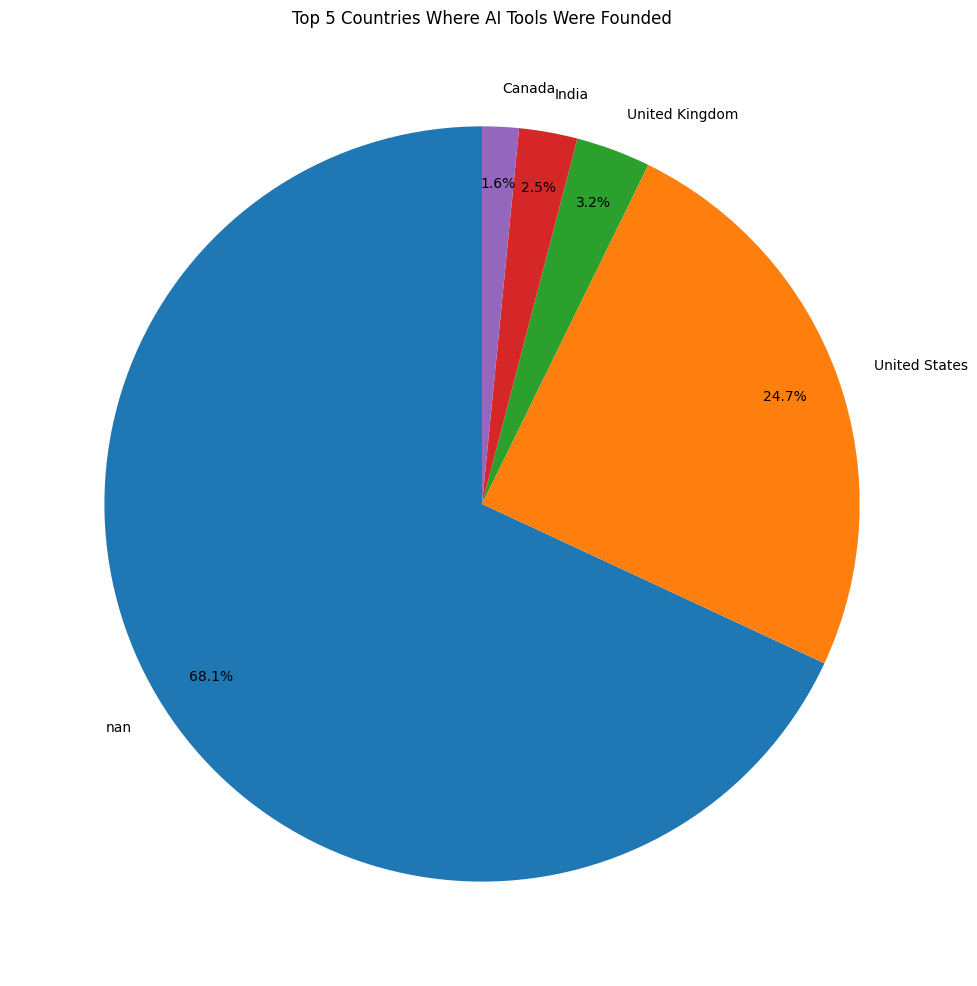

In [70]:
#Country column

country_counts = df_ai_tools['Country'].value_counts().head(5)
print(country_counts)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
country_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, pctdistance=0.85, legend=False)
plt.title('Top 5 Countries Where AI Tools Were Founded')
plt.ylabel('')
plt.tight_layout()
plt.show()

industry
nan                                  8935
information technology & services    5945
marketing & advertising               223
Name: count, dtype: int64


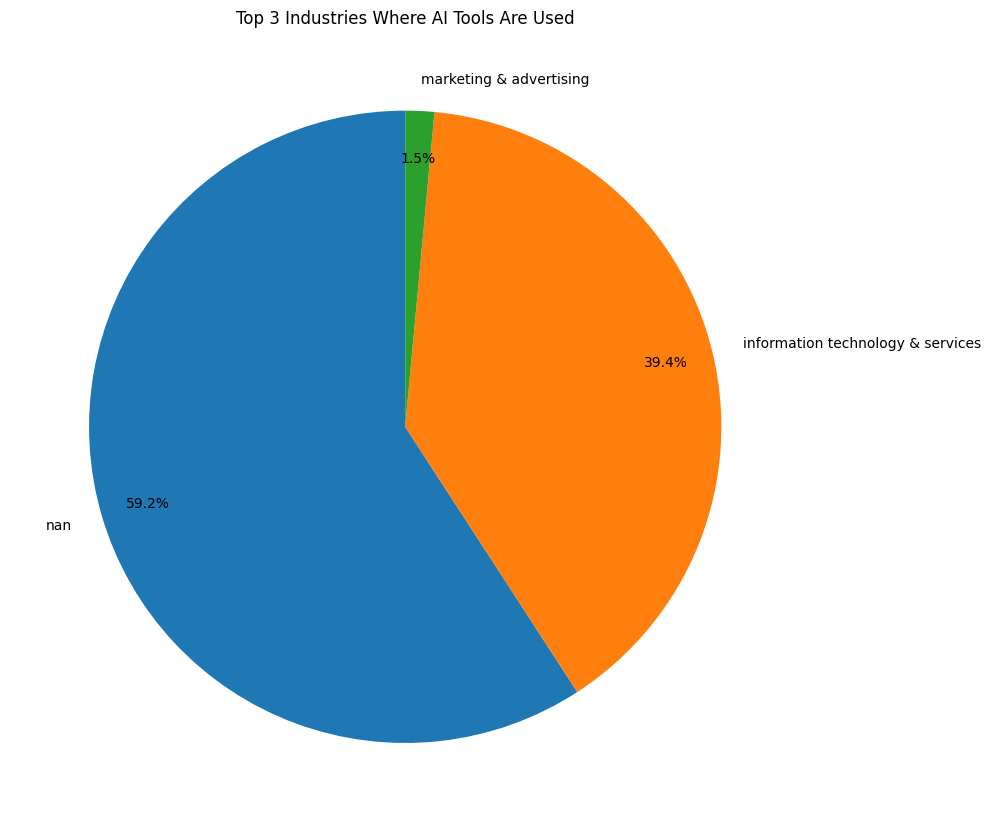

In [71]:
#industry column

industry_counts = df_ai_tools['industry'].value_counts().head(3)
print(industry_counts)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
industry_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, pctdistance=0.85, legend=False)
plt.title('Top 3 Industries Where AI Tools Are Used')
plt.ylabel('')
plt.tight_layout()
plt.show()

technologies_single
nan                   9129
Mobile Friendly       6386
Google Tag Manager    5200
Gmail                 5177
Google Apps           5177
AI                    4175
Cloudflare DNS        2995
Amazon AWS            2939
Remote                2386
Google Font API       2379
Name: count, dtype: int64


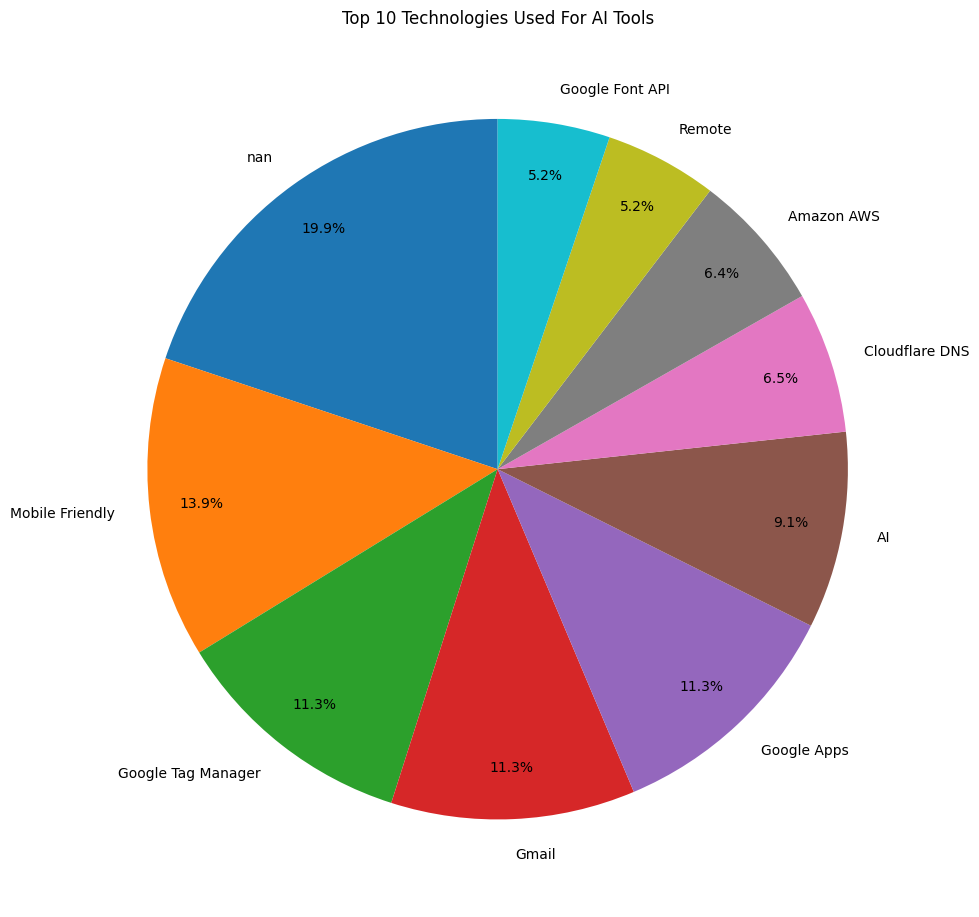

In [72]:
#technologies column

#split technologies into lists, strip spaces, and stack into one column
technologies_single = df_ai_tools['technologies'].astype(str).str.split(',').apply(pd.Series).stack().str.strip()

#convert back to a dataframe with the same column name
df_technologies = technologies_single.reset_index(drop=True).to_frame(name='technologies_single')

technologies_counts = df_technologies['technologies_single'].value_counts().head(10)
print(technologies_counts)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
technologies_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, pctdistance=0.85, legend=False)
plt.title('Top 10 Technologies Used For AI Tools')
plt.ylabel('')
plt.tight_layout()
plt.show()

Website Status
Active           14038
Not Reachable     1059
Error              543
Error 403          481
Error 404          316
Name: count, dtype: int64


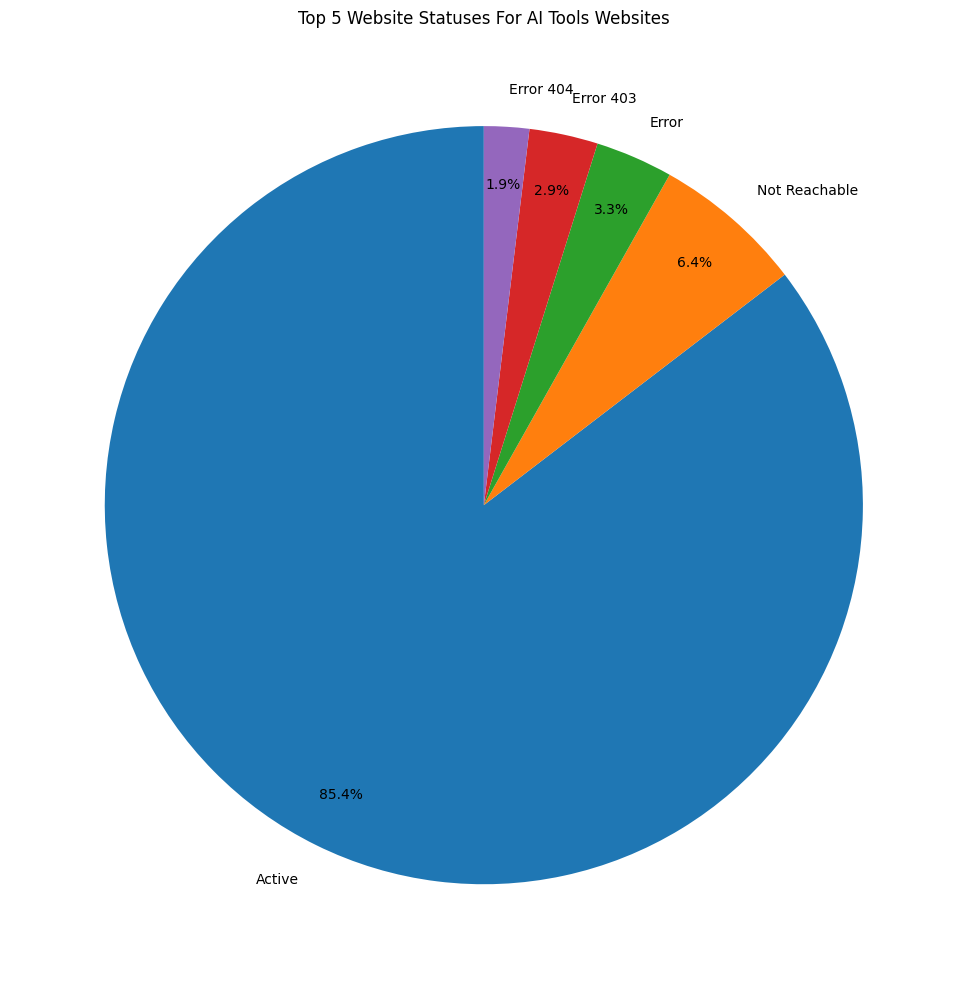

In [73]:
#Website Status column

website_status_counts = df_ai_tools['Website Status'].value_counts().head(5)
print(website_status_counts)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
website_status_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, pctdistance=0.85, legend=False)
plt.title('Top 5 Website Statuses For AI Tools Websites')
plt.ylabel('')
plt.tight_layout()
plt.show()